<a href="https://colab.research.google.com/github/Deeksha2508/Blood-Group-Detection-Using-Fingerprint/blob/main/Blood_Group_Detection_usingFingerPrintAnalysis_AI_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q scikit-image scikit-learn torch torchvision opencv-python-headless
!pip install -q matplotlib seaborn tqdm pillow grad-cam
print('✅ All libraries installed.')

✅ All libraries installed.


In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')
print('✅ Google Drive mounted.')
print('Files in My Drive:', os.listdir('/content/drive/MyDrive')[:10])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted.
Files in My Drive: ['TI+ SOC Mix July.pdf', 'Colab Notebooks', 'VisionV-Soft: Digital Eye Care Solution Validation  .gform', 'VisionV-Soft: Digital Eye Care Solution Validation   (Responses).gsheet', 'IMG_4448.MOV', 'fingerprint_dataset.zip', 'fingerprint_outputs', 'NatashaResume.pdf', 'FF4A87FD-A520-4D1E-B2D6-4E4BACDB15A9.mp4', 'UHU005_report_Group3.pdf']


In [ ]:
import os, zipfile



ZIP_PATH = '/content/drive/MyDrive/fingerprint_dataset.zip'

DATASET_DIR = '/content/fingerprint_dataset'


if os.path.exists(ZIP_PATH) and not os.path.exists(DATASET_DIR):
    print(f'📦 Unzipping {ZIP_PATH} ...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall('/content/')
    print('✅ Unzipped!')


print(f'\n📂 Dataset directory: {DATASET_DIR}')
print('Contents:', sorted(os.listdir(DATASET_DIR)) if os.path.exists(DATASET_DIR) else '❌ NOT FOUND — check your path!')

# Expected classes
CLASSES = ['A+', 'A-', 'B+', 'B-', 'AB+', 'AB-', 'O+', 'O-']
NUM_CLASSES = 8
IMG_SIZE = 128


📂 Dataset directory: /content/fingerprint_dataset
Contents: ['A+', 'A-', 'AB+', 'AB-', 'B+', 'B-', 'O+', 'O-']


---
## STEP 3 — Verify Dataset Structure
This cell checks that all 8 subfolders exist and shows how many images are in each.

In [ ]:
import os
from collections import Counter

print('='*50)
print('DATASET VERIFICATION')
print('='*50)

total = 0
missing = []
counts = {}

for cls in CLASSES:
    folder = os.path.join(DATASET_DIR, cls)
    if not os.path.exists(folder):
        print(f'  ❌  {cls:<6}  → FOLDER NOT FOUND')
        missing.append(cls)
        continue
    imgs = [f for f in os.listdir(folder)
            if f.lower().endswith(('.bmp','.png','.jpg','.jpeg','.tif'))]
    counts[cls] = len(imgs)
    total += len(imgs)
    print(f'  ✅  {cls:<6}  → {len(imgs):>5} images')

print(f'\n  TOTAL: {total} images across {len(counts)} classes')

if missing:
    print(f'\n⚠️  Missing folders: {missing}')
    print('   → Check that your folder names match exactly (case-sensitive!)')
    print('   → Accepted names: A+  A-  B+  B-  AB+  AB-  O+  O-')
else:
    print('\n✅ All 8 classes found. Ready to train!')

DATASET VERIFICATION
  ✅  A+      →  1000 images
  ✅  A-      →  1000 images
  ✅  B+      →  1000 images
  ✅  B-      →  1000 images
  ✅  AB+     →  1000 images
  ✅  AB-     →  1000 images
  ✅  O+      →  1000 images
  ✅  O-      →  1000 images

  TOTAL: 8000 images across 8 classes

✅ All 8 classes found. Ready to train!


---
## STEP 4 — Preprocessing with CLAHE
CLAHE (Contrast Limited Adaptive Histogram Equalisation) enhances ridge visibility in fingerprint images.

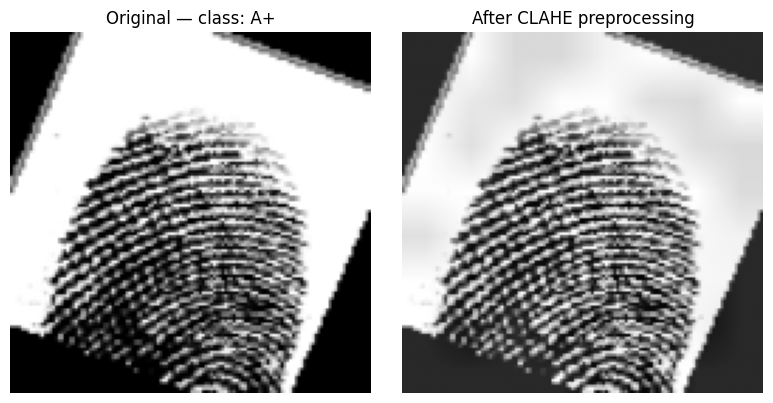

✅ Preprocessing function ready.


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def preprocess_image(img_path, size=IMG_SIZE):
    """
    Load → grayscale → resize → CLAHE → normalise.
    Returns a float32 numpy array in [0,1].
    """
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f'Cannot read image: {img_path}')
    img = cv2.resize(img, (size, size))
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(img)
    img = img.astype(np.float32) / 255.0
    return img

# Visual demo: show before/after CLAHE on one sample image
sample_class = [c for c in CLASSES if c in os.listdir(DATASET_DIR)][0]
sample_folder = os.path.join(DATASET_DIR, sample_class)
sample_file = [f for f in os.listdir(sample_folder)
               if f.lower().endswith(('.bmp','.png','.jpg'))][0]
sample_path = os.path.join(sample_folder, sample_file)

raw = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)
raw_resized = cv2.resize(raw, (IMG_SIZE, IMG_SIZE))
processed = preprocess_image(sample_path)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(raw_resized, cmap='gray')
axes[0].set_title(f'Original — class: {sample_class}', fontsize=12)
axes[0].axis('off')
axes[1].imshow(processed, cmap='gray')
axes[1].set_title('After CLAHE preprocessing', fontsize=12)
axes[1].axis('off')
plt.tight_layout()
plt.savefig('preprocessing_demo.png', dpi=100, bbox_inches='tight')
plt.show()
print('✅ Preprocessing function ready.')

In [ ]:
def compute_metrics(img):
    # Standard deviation (contrast)
    std = np.std(img)

    # Entropy
    hist = cv2.calcHist([img.astype('uint8')],[0],None,[256],[0,256])
    hist = hist / hist.sum()
    entropy = -np.sum(hist * np.log2(hist + 1e-7))

    return std, entropy

---
## STEP 5 — Feature Extraction: GLCM + LBP + Gabor (154 features total)
| Method | Features |
|--------|----------|
| GLCM | 48 texture co-occurrence features |
| LBP | 26 local binary pattern histogram features |
| Gabor | 80 ridge-orientation features (8 angles × 5 scales) |

In [ ]:
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from skimage.util import view_as_windows
import numpy as np
import cv2

FEATURE_TYPE = 'dlbp'
# 'ltrp', 'lbp_basic', 'lbp_uniform', 'multiblock', 'oclbp', 'dlpb','tlbp'


# ---------- GLCM ----------
def extract_glcm_features(img_float):
    img_uint8 = (img_float * 255).astype(np.uint8)

    glcm = graycomatrix(
        img_uint8,
        distances=[1, 2],
        angles=[0, np.pi/4],
        levels=256,
        symmetric=True,
        normed=True
    )

    feats = []
    for prop in ['contrast', 'homogeneity']:
        vals = graycoprops(glcm, prop)
        feats.extend(vals.flatten())

    return np.array(feats)


# ---------- LTrP ----------
def extract_ltrp_features(img_float, t=10):
    img = (img_float * 255).astype(np.int32)

    patches = view_as_windows(img, (3, 3))
    center = patches[:, :, 1, 1]

    pos_feats, neg_feats, neu_feats = [], [], []

    for i in range(3):
        for j in range(3):
            if i == 1 and j == 1:
                continue

            neighbor = patches[:, :, i, j]
            diff = neighbor - center

            pos = diff >= t
            neg = diff <= -t
            neu = (~pos & ~neg)

            pos_feats.append(np.mean(pos))
            neg_feats.append(np.mean(neg))
            neu_feats.append(np.mean(neu))

    return np.concatenate([pos_feats, neg_feats, neu_feats])


# ---------- BASIC LBP ----------
def extract_lbp_basic(img_float):
    img = (img_float * 255).astype(np.uint8)
    lbp = local_binary_pattern(img, 8, 1, method='default')

    hist, _ = np.histogram(lbp.ravel(), bins=256, range=(0,256))
    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-6)

    return hist


# ---------- UNIFORM LBP ----------
def extract_lbp_uniform(img_float):
    img = (img_float * 255).astype(np.uint8)
    lbp = local_binary_pattern(img, 8, 1, method='uniform')

    hist, _ = np.histogram(lbp.ravel(), bins=10, range=(0,10))
    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-6)

    return hist


# ---------- MULTI-BLOCK LBP ----------
def extract_multiblock_lbp(img_float):
    img = (img_float * 255).astype(np.uint8)

    h, w = img.shape
    blocks = 4
    bh, bw = h // blocks, w // blocks

    features = []

    for i in range(blocks):
        for j in range(blocks):
            block = img[i*bh:(i+1)*bh, j*bw:(j+1)*bw]
            lbp = local_binary_pattern(block, 8, 1, method='uniform')

            hist, _ = np.histogram(lbp.ravel(), bins=10, range=(0,10))
            hist = hist.astype("float")
            hist /= (hist.sum() + 1e-6)

            features.extend(hist)

    return np.array(features)


# ---------- OCLBP (SIMPLIFIED OVERLAP VERSION) ----------
def extract_oclbp(img_float):
    img = (img_float * 255).astype(np.uint8)

    h, w = img.shape
    block_size = 16
    stride = 8   # overlap

    features = []

    for i in range(0, h - block_size, stride):
        for j in range(0, w - block_size, stride):
            block = img[i:i+block_size, j:j+block_size]

            lbp = local_binary_pattern(block, 8, 1, method='uniform')
            hist, _ = np.histogram(lbp.ravel(), bins=10, range=(0,10))

            hist = hist.astype("float")
            hist /= (hist.sum() + 1e-6)

            features.extend(hist)

    return np.array(features)

#---------tLBP----------------

def extract_tlbp(img_float):
    img = (img_float * 255).astype(np.uint8)

    lbp = local_binary_pattern(img, 8, 1, method='default')
    lbp = lbp.astype(np.uint8)

    transitions = []

    for val in lbp.ravel():
        binary = format(val, '08b')  # 8-bit pattern

        count = 0
        for i in range(8):
            if binary[i] != binary[(i+1) % 8]:
                count += 1

        transitions.append(count)

    hist, _ = np.histogram(transitions, bins=9, range=(0,9))
    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-6)

    return hist

#------------dLBP-----------
def extract_dlbp(img_float):
    img = (img_float * 255).astype(np.int32)

    patches = view_as_windows(img, (3, 3))
    center = patches[:, :, 1, 1]

    # Directions: horizontal, vertical, diagonal1, diagonal2
    directions = [
        ((1, 0), (1, 2)),  # left-right
        ((0, 1), (2, 1)),  # top-bottom
        ((0, 0), (2, 2)),  # diag \
        ((0, 2), (2, 0))   # diag /
    ]

    features = []

    for d1, d2 in directions:
        p1 = patches[:, :, d1[0], d1[1]]
        p2 = patches[:, :, d2[0], d2[1]]

        diff1 = p1 - center
        diff2 = p2 - center

        code = (diff1 > 0).astype(int) * 2 + (diff2 > 0).astype(int)

        hist, _ = np.histogram(code.ravel(), bins=4, range=(0,4))
        hist = hist.astype("float")
        hist /= (hist.sum() + 1e-6)

        features.extend(hist)

    return np.array(features)

# ---------- GABOR ----------
def extract_gabor_features(img_float):
    feats = []
    img = (img_float * 255).astype(np.float32)

    for theta in np.linspace(0, np.pi, 4, endpoint=False):
        kernel = cv2.getGaborKernel(
            (21, 21), 2, theta, 10.0, 0.5, 0, ktype=cv2.CV_32F
        )

        filtered = cv2.filter2D(img, cv2.CV_32F, kernel)
        feats.append(filtered.mean())
        feats.append(filtered.std())

    return np.array(feats)


# ---------- FINAL COMBINED --------
def extract_all_features(img_float):
    glcm_feats = extract_glcm_features(img_float)
    gabor_feats = extract_gabor_features(img_float)

    if FEATURE_TYPE == 'ltrp':
        local_feats = extract_ltrp_features(img_float)
    elif FEATURE_TYPE == 'lbp_basic':
        local_feats = extract_lbp_basic(img_float)
    elif FEATURE_TYPE == 'lbp_uniform':
        local_feats = extract_lbp_uniform(img_float)
    elif FEATURE_TYPE == 'multiblock':
        local_feats = extract_multiblock_lbp(img_float)
    elif FEATURE_TYPE == 'oclbp':
        local_feats = extract_oclbp(img_float)
    elif FEATURE_TYPE == 'tlbp':
        local_feats = extract_tlbp(img_float)
    elif FEATURE_TYPE == 'dlbp':
        local_feats = extract_dlbp(img_float)
    else:
        raise ValueError(f"Unknown FEATURE_TYPE: {FEATURE_TYPE}")

    return np.concatenate([glcm_feats, local_feats, gabor_feats])

# ---------- QUICK TEST ----------
try:
    test_img = preprocess_image(sample_path)
    test_feat = extract_all_features(test_img)

    print(f'✅ Feature vector length: {len(test_feat)}')
    print(f'   Feature Type: {FEATURE_TYPE}')

except NameError as e:
    print(f"⚠️ Run preprocessing step first: {e}")

✅ Feature vector length: 32
   Feature Type: dlbp


In [ ]:
from tqdm import tqdm
import numpy as np

print('Building feature dataset (this may take 5–15 minutes for 7000 images)...')
print('Progress is shown per class below.\n')

X_all = []   # feature vectors
y_all = []   # integer labels
label_map = {cls: idx for idx, cls in enumerate(CLASSES)}

for cls in CLASSES:
    folder = os.path.join(DATASET_DIR, cls)
    if not os.path.exists(folder):
        print(f'  ⚠️  Skipping {cls} — folder not found')
        continue
    files = [f for f in os.listdir(folder)
             if f.lower().endswith(('.bmp','.png','.jpg','.jpeg','.tif'))]
    for fname in tqdm(files, desc=f'{cls:<5}', leave=True):
        fpath = os.path.join(folder, fname)
        try:
            img = preprocess_image(fpath)
            feat = extract_all_features(img)
            X_all.append(feat)
            y_all.append(label_map[cls])
        except Exception as e:
            print(f'  ⚠️  Skipped {fname}: {e}')

X = np.array(X_all)
y = np.array(y_all)

print(f'\n✅ Feature matrix shape: {X.shape}')
print(f'   Labels shape:         {y.shape}')
print(f'   Classes:              {CLASSES}')

# Save features so you don't have to recompute
np.save('X_features.npy', X)
np.save('y_labels.npy', y)
print('\n💾 Features saved to X_features.npy and y_labels.npy')

Building feature dataset (this may take 5–15 minutes for 7000 images)...
Progress is shown per class below.



O-   : 100%|██████████| 1000/1000 [00:23<00:00, 42.57it/s]


✅ Feature matrix shape: (8000, 32)
   Labels shape:         (8000,)
   Classes:              ['A+', 'A-', 'B+', 'B-', 'AB+', 'AB-', 'O+', 'O-']

💾 Features saved to X_features.npy and y_labels.npy


---
## STEP 6 — Train ML Models: SVM + Random Forest + Logistic Regression + Gradient Boosting
Uses the 154-dimensional feature vector. 5-fold stratified cross-validation.

Training samples: 6400
Test samples:     1600

Training SVM...

Training Random Forest...

Training Logistic Regression...

Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:04:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



✅ SVM Accuracy: 68.06%
✅ RF Accuracy: 59.88%
✅ LR Accuracy: 67.06%
✅ XGB Accuracy: 63.06%

--- Cross Validation ---
SVM: 69.47% ± 1.49%
Random Forest: 61.29% ± 0.83%
Logistic Regression: 68.73% ± 0.90%


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:06:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:06:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:07:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:07:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

XGBoost: 64.29% ± 0.79%

--- Classification Reports ---

SVM:
               precision    recall  f1-score   support

          A+       0.79      0.74      0.77       200
          A-       0.68      0.64      0.66       200
          B+       0.68      0.69      0.68       200
          B-       0.80      0.85      0.82       200
         AB+       0.58      0.60      0.59       200
         AB-       0.59      0.65      0.62       200
          O+       0.72      0.73      0.73       200
          O-       0.60      0.53      0.56       200

    accuracy                           0.68      1600
   macro avg       0.68      0.68      0.68      1600
weighted avg       0.68      0.68      0.68      1600


Random Forest:
               precision    recall  f1-score   support

          A+       0.73      0.65      0.69       200
          A-       0.58      0.51      0.54       200
          B+       0.57      0.64      0.60       200
          B-       0.72      0.78      0.75       20

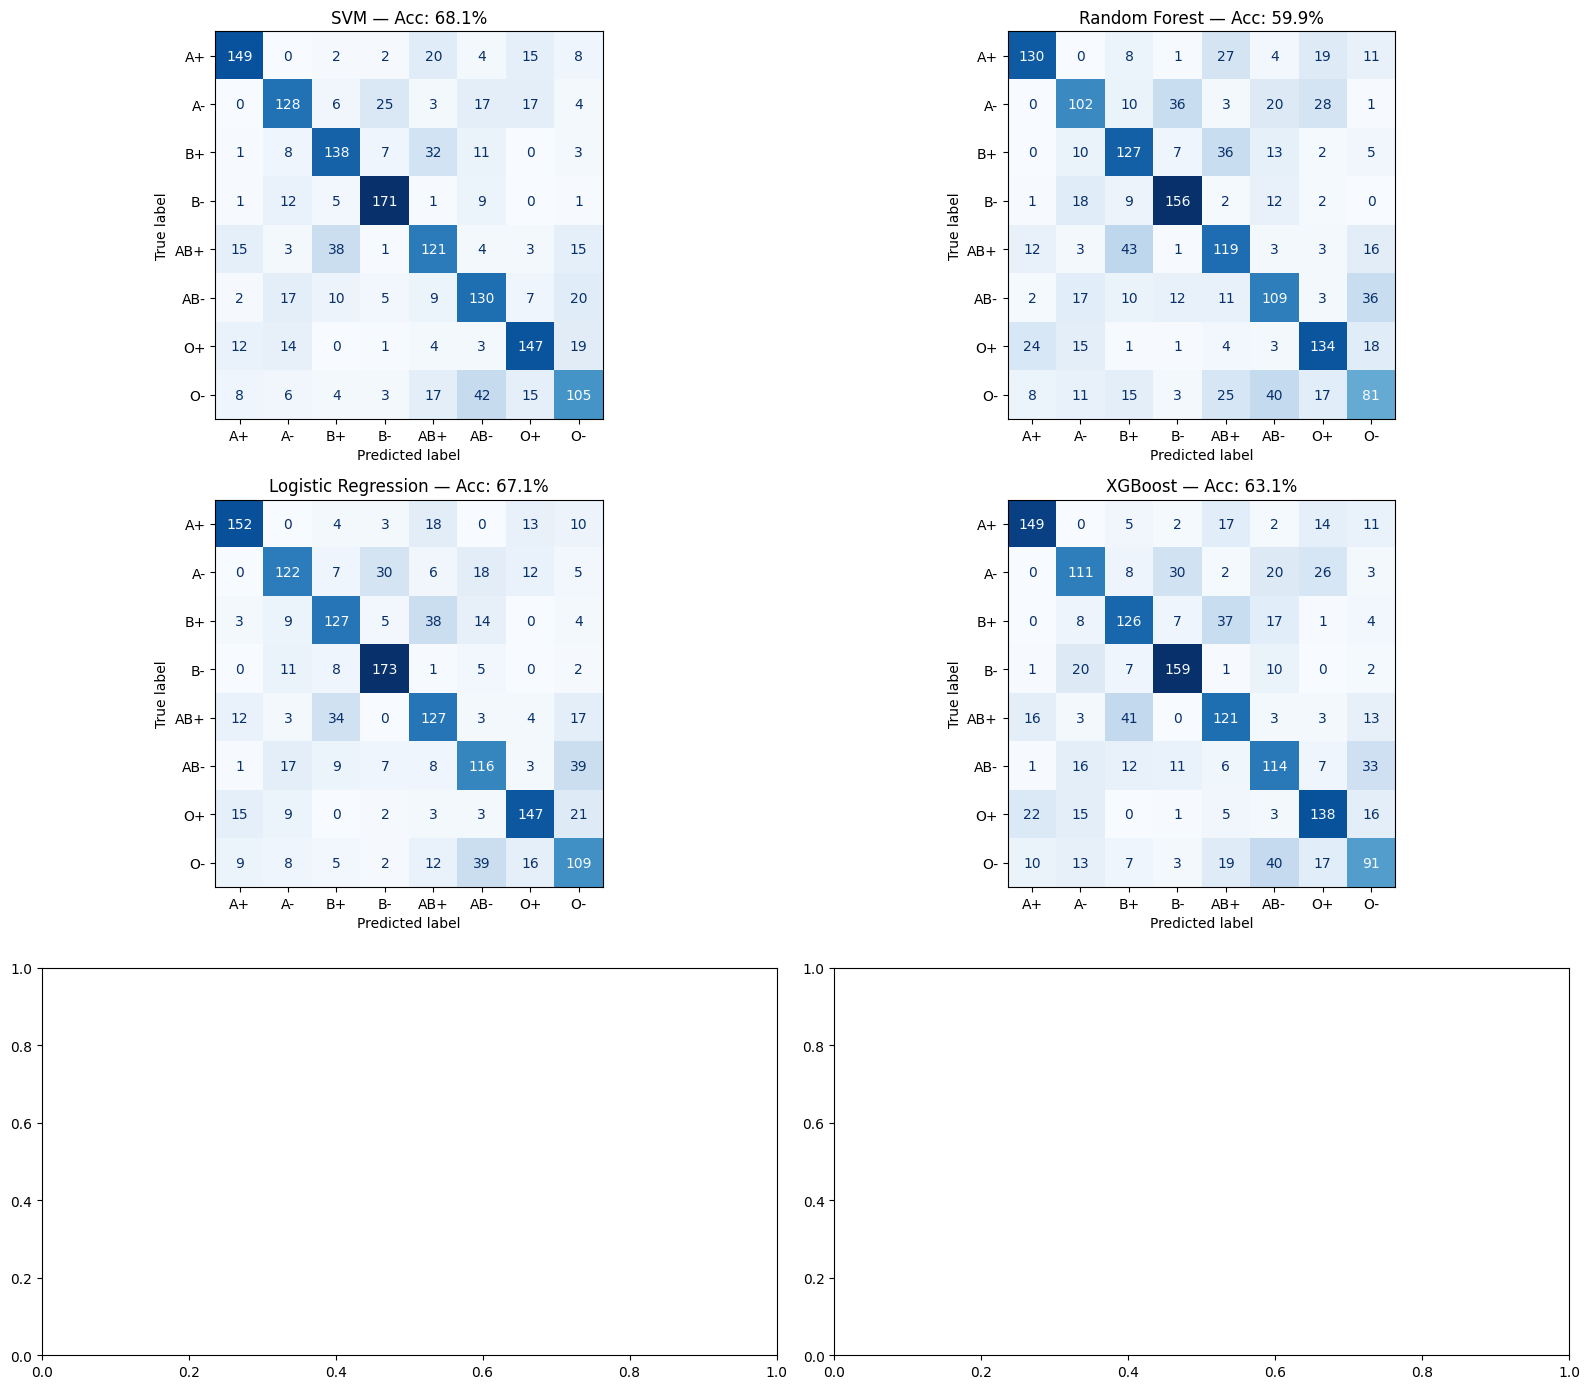


💾 Models saved successfully!


In [ ]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, ConfusionMatrixDisplay)

import matplotlib.pyplot as plt
import numpy as np
import joblib

# =========================
# 🔷 SCALE FEATURES
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================
# 🔷 TRAIN / TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y)

print(f'Training samples: {len(X_train)}')
print(f'Test samples:     {len(X_test)}')

# =========================
# 🔷 TRAIN MODELS
# =========================

# ---- SVM ----
print('\nTraining SVM...')
svm = SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42)
svm.fit(X_train, y_train)
svm_preds = svm.predict(X_test)
svm_acc = accuracy_score(y_test, svm_preds)

# ---- Random Forest ----
print('\nTraining Random Forest...')
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_preds)

# ---- Logistic Regression ----
print('\nTraining Logistic Regression...')
lr = LogisticRegression(max_iter=1000, n_jobs=-1)
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)
lr_acc = accuracy_score(y_test, lr_preds)

# ---- XGBoost ----
print('\nTraining XGBoost...')
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    use_label_encoder=False,
    n_jobs=-1,
    random_state=42
)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_preds)


# =========================
# 🔷 ACCURACY SUMMARY
# =========================
print(f'\n✅ SVM Accuracy: {svm_acc*100:.2f}%')
print(f'✅ RF Accuracy: {rf_acc*100:.2f}%')
print(f'✅ LR Accuracy: {lr_acc*100:.2f}%')
print(f'✅ XGB Accuracy: {xgb_acc*100:.2f}%')

# =========================
# 🔷 CROSS VALIDATION
# =========================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def run_cv(model, name):
    scores = cross_val_score(model, X_scaled, y, cv=cv, scoring='accuracy')
    print(f'{name}: {scores.mean()*100:.2f}% ± {scores.std()*100:.2f}%')

print('\n--- Cross Validation ---')
run_cv(svm, 'SVM')
run_cv(rf, 'Random Forest')
run_cv(lr, 'Logistic Regression')
run_cv(xgb, 'XGBoost')

# =========================
# 🔷 CLASSIFICATION REPORTS
# =========================
print('\n--- Classification Reports ---')

print('\nSVM:\n', classification_report(y_test, svm_preds, target_names=CLASSES))
print('\nRandom Forest:\n', classification_report(y_test, rf_preds, target_names=CLASSES))
print('\nLogistic Regression:\n', classification_report(y_test, lr_preds, target_names=CLASSES))
print('\nXGBoost:\n', classification_report(y_test, xgb_preds, target_names=CLASSES))


# =========================
# 🔷 CONFUSION MATRICES
# =========================
fig, axes = plt.subplots(3, 2, figsize=(16, 14))

models_preds = [
    (svm_preds, 'SVM', svm_acc),
    (rf_preds, 'Random Forest', rf_acc),
    (lr_preds, 'Logistic Regression', lr_acc),
    (xgb_preds, 'XGBoost', xgb_acc),
]

for ax, (preds, title, acc) in zip(axes.ravel(), models_preds):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASSES)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{title} — Acc: {acc*100:.1f}%')

plt.tight_layout()
plt.savefig('ml_confusion_matrices_all.png', dpi=120)
plt.show()

# =========================
# 🔷 SAVE MODELS
# =========================
joblib.dump(svm, 'svm_model.pkl')
joblib.dump(rf, 'rf_model.pkl')
joblib.dump(lr, 'logistic_model.pkl')
joblib.dump(xgb, 'xgb_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print('\n💾 Models saved successfully!')

                 Model  Accuracy  Precision    Recall  F1 Score
0                  SVM  0.680625   0.680574  0.680625  0.679770
1        Random Forest  0.598750   0.598416  0.598750  0.596868
2  Logistic Regression  0.670625   0.671209  0.670625  0.670218
3              XGBoost  0.630625   0.628343  0.630625  0.628874


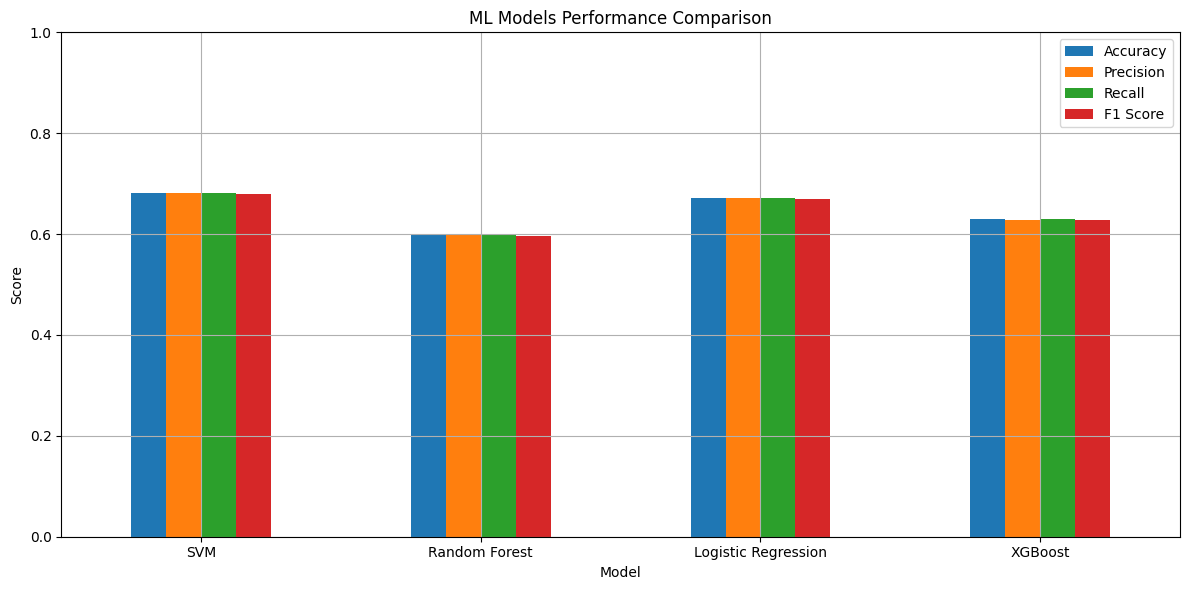

In [ ]:
# =========================
# 🔷 PLOT METRICS (NEW CELL)
# =========================

from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt

models = [
    ('SVM', svm_preds),
    ('Random Forest', rf_preds),
    ('Logistic Regression', lr_preds),
    ('XGBoost', xgb_preds)
]

results = []

for name, preds in models:
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average='weighted')
    rec = recall_score(y_test, preds, average='weighted')
    f1 = f1_score(y_test, preds, average='weighted')

    results.append([name, acc, prec, rec, f1])

metrics_df = pd.DataFrame(results, columns=[
    'Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score'
])

print(metrics_df)

# ---- Plot ----
metrics_df.set_index('Model').plot(kind='bar', figsize=(12,6))

plt.title('ML Models Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(True)

plt.tight_layout()
plt.savefig('ml_models_comparison.png', dpi=120)
plt.show()


---
## STEP 7 — Train CNN: ResNet18 (Transfer Learning)
ResNet18 pretrained on ImageNet, fine-tuned on our fingerprint dataset. Uses class-weighted loss to handle class imbalance.

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torch.optim.lr_scheduler import CosineAnnealingLR
import numpy as np
from PIL import Image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# ---- Dataset class ----
class FingerprintDataset(Dataset):
    def __init__(self, dataset_dir, classes, transform=None):
        self.samples = []     # list of (path, label_index)
        self.classes = classes
        self.transform = transform
        self.label_map = {cls: idx for idx, cls in enumerate(classes)}

        for cls in classes:
            folder = os.path.join(dataset_dir, cls)
            if not os.path.exists(folder):
                continue
            for fname in os.listdir(folder):
                if fname.lower().endswith(('.bmp','.png','.jpg','.jpeg','.tif')):
                    self.samples.append((os.path.join(folder, fname),
                                         self.label_map[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')     # ResNet expects 3-channel
        if self.transform:
            img = self.transform(img)
        return img, label

# ---- Transforms ----
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])
val_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

# ---- Build full dataset, then split ----
full_dataset = FingerprintDataset(DATASET_DIR, CLASSES, transform=None)
n = len(full_dataset)
n_val  = int(0.20 * n)
n_train = n - n_val

from torch.utils.data import random_split
train_set, val_set = random_split(
    full_dataset, [n_train, n_val],
    generator=torch.Generator().manual_seed(42))

# Apply transforms separately
train_set.dataset.transform = train_transform   # Note: this sets transform for entire dataset
                                                 # Proper split done below via Subset

# Correct approach using Subset with separate transforms
from torch.utils.data import Subset

all_indices = list(range(n))
np.random.seed(42)
np.random.shuffle(all_indices)
train_idx = all_indices[:n_train]
val_idx   = all_indices[n_train:]

train_data = FingerprintDataset(DATASET_DIR, CLASSES, transform=train_transform)
val_data   = FingerprintDataset(DATASET_DIR, CLASSES, transform=val_transform)

train_subset = Subset(train_data, train_idx)
val_subset   = Subset(val_data,   val_idx)

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True,
                           num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_subset, batch_size=64, shuffle=False,
                           num_workers=2, pin_memory=True)

print(f'\nTrain samples: {len(train_subset)}')
print(f'Val samples:   {len(val_subset)}')
print(f'Batch size:    32')
print(f'Train batches: {len(train_loader)}')

Using device: cuda
GPU: Tesla T4

Train samples: 6400
Val samples:   1600
Batch size:    32
Train batches: 200


In [ ]:
# ---- Build ResNet18 ----
cnn = models.resnet18(pretrained=True)

# Replace final fully-connected layer for 8 classes
in_features = cnn.fc.in_features
cnn.fc = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, NUM_CLASSES)
)
cnn = cnn.to(device)

# ---- Class weights (handle imbalance) ----
class_counts = np.bincount(y, minlength=NUM_CLASSES)
class_weights = 1.0 / (class_counts + 1)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=weights_tensor)

# ---- Optimiser + LR scheduler ----
optimizer = torch.optim.Adam(cnn.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=30, eta_min=1e-5)

total_params = sum(p.numel() for p in cnn.parameters())
trainable   = sum(p.numel() for p in cnn.parameters() if p.requires_grad)
print(f'Model: ResNet18')
print(f'Total params:     {total_params:,}')
print(f'Trainable params: {trainable:,}')
print(f'Loss: CrossEntropyLoss with class weights')
print(f'Optimizer: Adam (lr=1e-3)')
print(f'Scheduler: CosineAnnealingLR')

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Model: ResNet18
Total params:     11,309,896
Trainable params: 11,309,896
Loss: CrossEntropyLoss with class weights
Optimizer: Adam (lr=1e-3)
Scheduler: CosineAnnealingLR


Training ResNet18 for 30 epochs on cuda...

Epoch   1/30  Train Loss: 1.1990  Train Acc: 53.6%  Val Loss: 0.7601  Val Acc: 73.1%
Epoch   5/30  Train Loss: 0.5739  Train Acc: 78.5%  Val Loss: 0.3774  Val Acc: 84.9%
Epoch  10/30  Train Loss: 0.4634  Train Acc: 83.3%  Val Loss: 0.3150  Val Acc: 87.7%
Epoch  15/30  Train Loss: 0.3739  Train Acc: 85.5%  Val Loss: 0.4112  Val Acc: 83.5%
Epoch  20/30  Train Loss: 0.2774  Train Acc: 89.3%  Val Loss: 0.2791  Val Acc: 88.8%
Epoch  25/30  Train Loss: 0.1863  Train Acc: 92.6%  Val Loss: 0.2145  Val Acc: 91.5%
Epoch  30/30  Train Loss: 0.1481  Train Acc: 94.7%  Val Loss: 0.1916  Val Acc: 92.5%

✅ Training complete. Best Val Accuracy: 93.56%


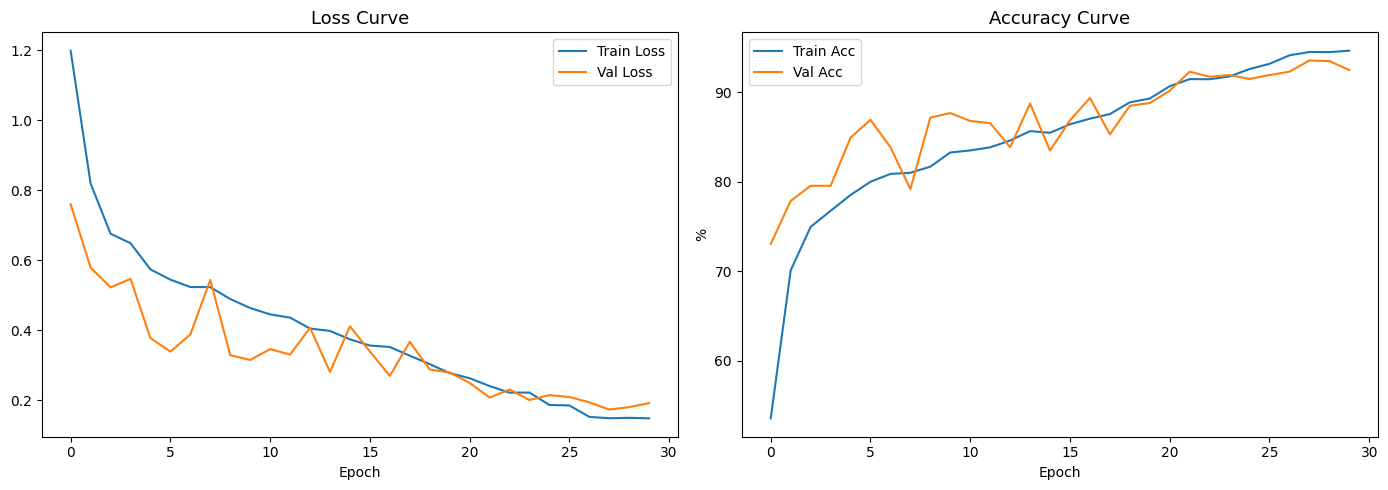

In [ ]:
# ---- Training loop ----
EPOCHS = 30
train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_acc = 0.0

print(f'Training ResNet18 for {EPOCHS} epochs on {device}...\n')

for epoch in range(1, EPOCHS + 1):
    # --- Train ---
    cnn.train()
    running_loss, correct, total = 0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out = cnn(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        preds = out.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += imgs.size(0)
    train_loss = running_loss / total
    train_acc  = correct / total

    # --- Validate ---
    cnn.eval()
    v_loss, v_correct, v_total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out = cnn(imgs)
            v_loss += criterion(out, labels).item() * imgs.size(0)
            v_correct += (out.argmax(1) == labels).sum().item()
            v_total   += imgs.size(0)
    val_loss = v_loss / v_total
    val_acc  = v_correct / v_total

    train_losses.append(train_loss); val_losses.append(val_loss)
    train_accs.append(train_acc);   val_accs.append(val_acc)

    scheduler.step()

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(cnn.state_dict(), 'best_cnn.pth')

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:>3}/{EPOCHS}  '
              f'Train Loss: {train_loss:.4f}  Train Acc: {train_acc*100:.1f}%  '
              f'Val Loss: {val_loss:.4f}  Val Acc: {val_acc*100:.1f}%')

print(f'\n✅ Training complete. Best Val Accuracy: {best_val_acc*100:.2f}%')

# ---- Plot training curves ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(val_losses, label='Val Loss')
axes[0].set_title('Loss Curve', fontsize=13)
axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot([a*100 for a in train_accs], label='Train Acc')
axes[1].plot([a*100 for a in val_accs], label='Val Acc')
axes[1].set_title('Accuracy Curve', fontsize=13)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('%'); axes[1].legend()

plt.tight_layout()
plt.savefig('cnn_training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

CNN (ResNet18) Test Accuracy: 93.56%

              precision    recall  f1-score   support

          A+       0.93      0.98      0.95       185
          A-       0.85      0.96      0.90       188
          B+       0.96      0.92      0.94       207
          B-       0.95      0.98      0.97       207
         AB+       0.95      0.88      0.92       204
         AB-       0.95      0.94      0.95       218
          O+       0.98      0.87      0.92       183
          O-       0.92      0.95      0.93       208

    accuracy                           0.94      1600
   macro avg       0.94      0.94      0.94      1600
weighted avg       0.94      0.94      0.94      1600



<Figure size 800x600 with 0 Axes>

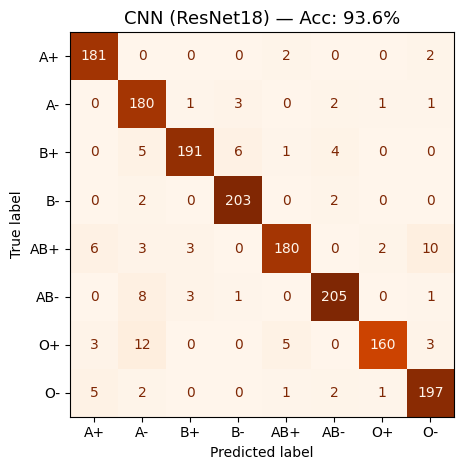


💾 CNN probabilities saved for fusion step.


In [ ]:
# ---- Evaluate CNN on test set ----
cnn.load_state_dict(torch.load('best_cnn.pth'))
cnn.eval()

all_preds, all_labels = [], []
cnn_probs = []   # save probabilities for fusion in STEP 8

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        out = cnn(imgs)
        probs = torch.softmax(out, dim=1).cpu().numpy()
        preds = out.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
        cnn_probs.extend(probs)

cnn_acc = accuracy_score(all_labels, all_preds)
print(f'CNN (ResNet18) Test Accuracy: {cnn_acc*100:.2f}%\n')
print(classification_report(all_labels, all_preds, target_names=CLASSES))

# Confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=CLASSES)
disp.plot(cmap='Oranges', colorbar=False)
plt.title(f'CNN (ResNet18) — Acc: {cnn_acc*100:.1f}%', fontsize=13)
plt.tight_layout()
plt.savefig('cnn_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

cnn_probs_array = np.array(cnn_probs)   # shape: (n_test, 8)
print(f'\n💾 CNN probabilities saved for fusion step.')

---
## STEP 8 — Late Fusion Ensemble
Combine SVM + Random Forest + CNN probabilities using weighted average.
CNN gets highest weight (0.5) since it sees raw image features directly.


🔧 Auto Weights:
CNN=0.22, SVM=0.18, RF=0.22, LR=0.16, XGB=0.22
              FINAL RESULTS SUMMARY
  SVM alone:            76.06%
  Random Forest alone:  91.00%
  Logistic Regression:  68.88%
  XGBoost:              91.50%
  CNN alone:            93.56%
------------------------------------------------------------
  🔥 Late Fusion:        94.25%  ← BEST

Target accuracy: ≥91%
✅ Target reached!

--- Fusion Classification Report ---
              precision    recall  f1-score   support

          A+       0.97      0.96      0.97       185
          A-       0.93      0.91      0.92       188
          B+       0.96      0.95      0.95       207
          B-       0.95      0.98      0.96       207
         AB+       0.93      0.92      0.92       204
         AB-       0.93      0.94      0.93       218
          O+       0.95      0.95      0.95       183
          O-       0.93      0.93      0.93       208

    accuracy                           0.94      1600
   macro avg       0.94 

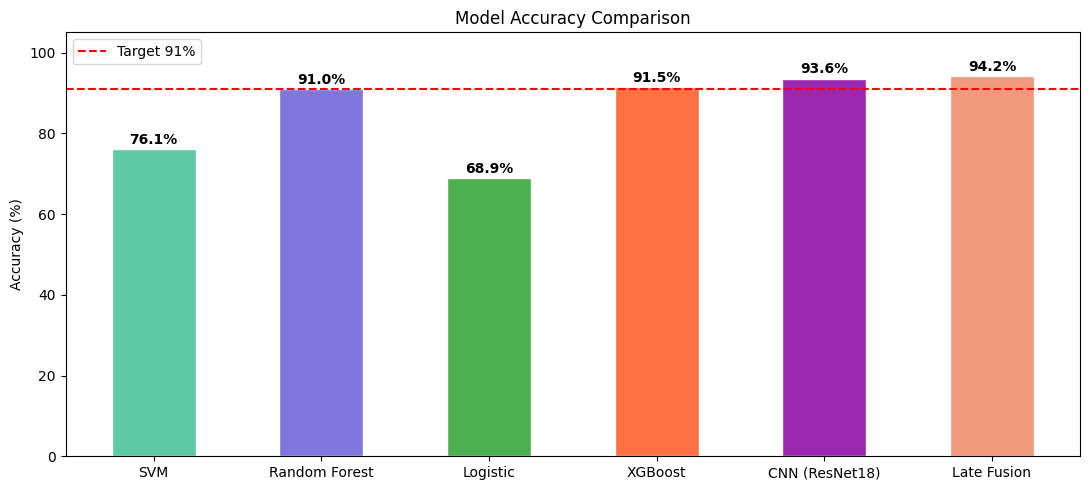

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

# =========================
# 🔷 GET VALIDATION DATA
# =========================
X_val_scaled = X_scaled[val_idx]
y_val        = y[val_idx]

# =========================
# 🔷 GET ALL MODEL PROBS
# =========================
svm_probs_val = svm.predict_proba(X_val_scaled)
rf_probs_val  = rf.predict_proba(X_val_scaled)
lr_probs_val  = lr.predict_proba(X_val_scaled)
xgb_probs_val = xgb.predict_proba(X_val_scaled)   # ✅ REPLACED
cnn_probs_val = cnn_probs_array


# =========================
# 🔷 AUTO WEIGHTING
# =========================
svm_acc_val = accuracy_score(y_val, svm.predict(X_val_scaled))
rf_acc_val  = accuracy_score(y_val, rf.predict(X_val_scaled))
lr_acc_val  = accuracy_score(y_val, lr.predict(X_val_scaled))
xgb_acc_val = accuracy_score(y_val, xgb.predict(X_val_scaled))
cnn_acc_val = cnn_acc

acc_list = np.array([
    cnn_acc_val,
    svm_acc_val,
    rf_acc_val,
    lr_acc_val,
    xgb_acc_val
])

weights = acc_list / acc_list.sum()

W_CNN, W_SVM, W_RF, W_LR, W_XGB = weights

print("\n🔧 Auto Weights:")
print(f"CNN={W_CNN:.2f}, SVM={W_SVM:.2f}, RF={W_RF:.2f}, "
      f"LR={W_LR:.2f}, XGB={W_XGB:.2f}") # Added missing closing quote


# =========================
# 🔷 LATE FUSION
# =========================
fused_probs = (
    W_CNN * cnn_probs_val +
    W_SVM * svm_probs_val +
    W_RF  * rf_probs_val +
    W_LR  * lr_probs_val +
    W_XGB * xgb_probs_val
)

fused_preds = fused_probs.argmax(axis=1)
fused_acc   = accuracy_score(y_val, fused_preds)


# =========================
# 🔷 RESULTS SUMMARY
# =========================
print('='*60)
print('              FINAL RESULTS SUMMARY')
print('='*60)

print(f'  SVM alone:            {svm_acc_val*100:.2f}%')
print(f'  Random Forest alone:  {rf_acc_val*100:.2f}%')
print(f'  Logistic Regression:  {lr_acc_val*100:.2f}%')
print(f'  XGBoost:              {xgb_acc_val*100:.2f}%')   # ✅ UPDATED
print(f'  CNN alone:            {cnn_acc_val*100:.2f}%')

print('-'*60)
print(f'  🔥 Late Fusion:        {fused_acc*100:.2f}%  ← BEST')
print('='*60)

print(f'\nTarget accuracy: ≥91%')
if fused_acc >= 0.91:
    print('✅ Target reached!')
else:
    print(f'⚠️ Gap: {(0.91 - fused_acc)*100:.1f}% — improve CNN or features')


# =========================
# 🔷 CLASSIFICATION REPORT
# =========================
print('\n--- Fusion Classification Report ---')
print(classification_report(y_val, fused_preds, target_names=CLASSES))


# =========================
# 🔷 BAR CHART
# =========================
import matplotlib.pyplot as plt

models_list = [
    'SVM', 'Random Forest', 'Logistic',
    'XGBoost',
    'CNN (ResNet18)', 'Late Fusion'
]

accs = [
    svm_acc_val * 100,
    rf_acc_val * 100,
    lr_acc_val * 100,
    xgb_acc_val * 100,
    cnn_acc_val * 100,
    fused_acc * 100
]

colors = ['#5DCAA5', '#7F77DD', '#4CAF50',
          '#FF7043', '#9C27B0',
          '#F0997B', '#EF9F27']

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(models_list, accs, color=colors, width=0.5, edgecolor='white')

ax.axhline(91, color='red', linestyle='--', linewidth=1.5, label='Target 91%')

for bar, acc in zip(bars, accs):
    ax.text(
        bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
        f'{acc:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

ax.set_ylim(0, 105)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Model Accuracy Comparison')
ax.legend()

plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=120)
plt.show()

---
## STEP 9 — Grad-CAM: Visualise Which Ridges Drive the Prediction
Grad-CAM highlights the fingerprint regions the CNN focused on

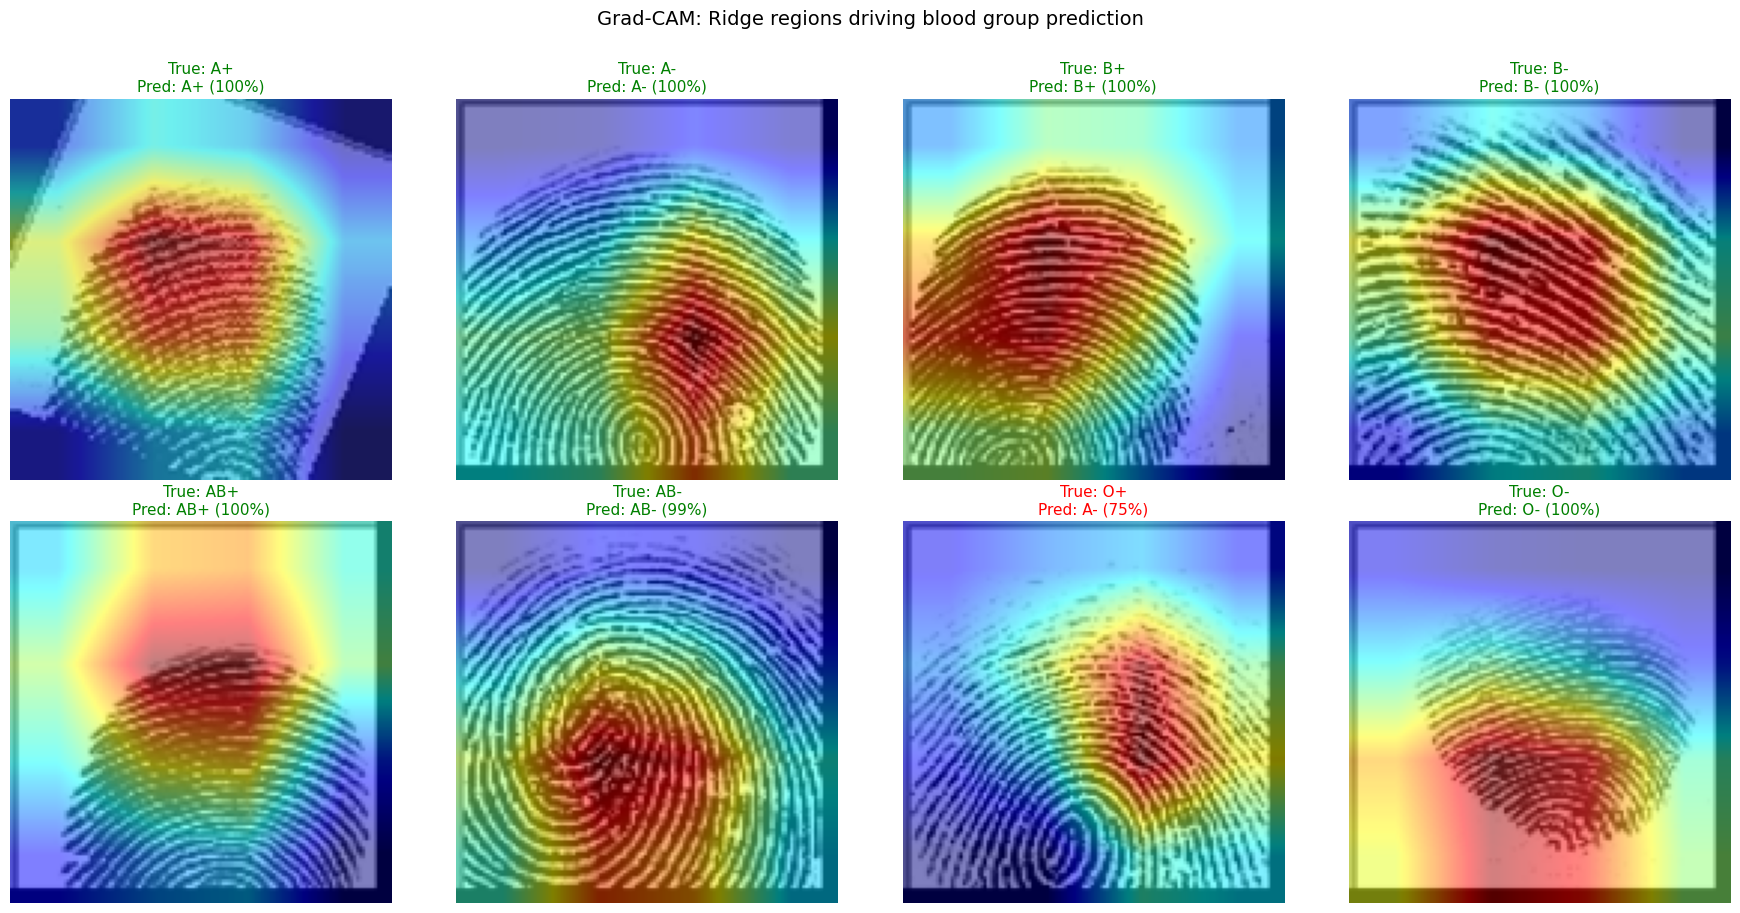

✅ Grad-CAM visualisation saved.


In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import matplotlib.pyplot as plt
import numpy as np
import cv2
from PIL import Image

# Target layer for Grad-CAM in ResNet18 = last conv block
target_layer = [cnn.layer4[-1]]

# Pick a sample image from each class for visualisation
cnn.load_state_dict(torch.load('best_cnn.pth'))
cnn.eval()

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

with GradCAM(model=cnn, target_layers=target_layer) as cam:
    for i, cls in enumerate(CLASSES):
        folder = os.path.join(DATASET_DIR, cls)
        if not os.path.exists(folder):
            continue
        files = [f for f in os.listdir(folder)
                 if f.lower().endswith(('.bmp','.png','.jpg'))]
        if not files:
            continue
        fpath = os.path.join(folder, files[0])

        # Prepare image for CNN
        img_pil = Image.open(fpath).convert('RGB').resize((128, 128))
        img_np  = np.array(img_pil).astype(np.float32) / 255.0
        tensor  = val_transform(img_pil).unsqueeze(0).to(device)

        # Run Grad-CAM
        target_cls = i
        grayscale_cam = cam(input_tensor=tensor,
                             targets=[ClassifierOutputTarget(target_cls)])
        grayscale_cam = grayscale_cam[0]

        # Overlay
        visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

        # Predicted class
        with torch.no_grad():
            out   = cnn(tensor)
            pred  = CLASSES[out.argmax(1).item()]
            conf  = torch.softmax(out, 1).max().item()

        axes[i].imshow(visualization)
        axes[i].set_title(f'True: {cls}\nPred: {pred} ({conf*100:.0f}%)',
                           fontsize=11, color='green' if pred==cls else 'red')
        axes[i].axis('off')

plt.suptitle('Grad-CAM: Ridge regions driving blood group prediction',
              fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('gradcam_visualisation.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Grad-CAM visualisation saved.')

---
## STEP 10 — Predict a Single New Fingerprint
Upload any fingerprint image and get an instant prediction with confidence scores from all models.

Upload a fingerprint image (BMP, PNG, or JPG):


Saving augmented_cluster_4_492.BMP to augmented_cluster_4_492.BMP


/tmp/ipykernel_1037/2191182997.py:97: UserWarning: Glyph 129656 (\N{DROP OF BLOOD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1037/2191182997.py:98: UserWarning: Glyph 129656 (\N{DROP OF BLOOD}) missing from font(s) DejaVu Sans.
  plt.savefig('single_prediction.png', dpi=120)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129656 (\N{DROP OF BLOOD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


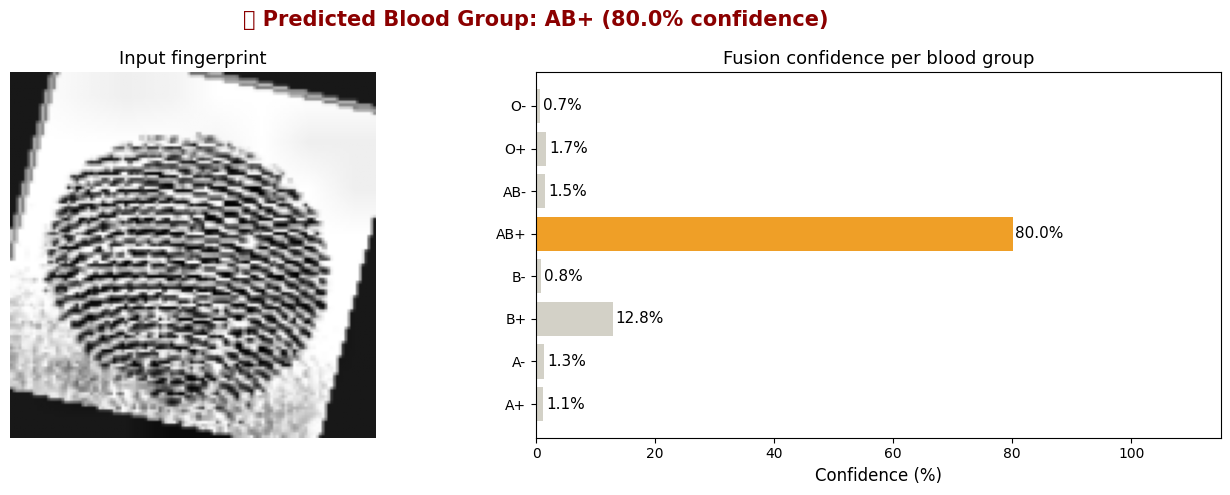

  FINAL PREDICTION: AB+
  CONFIDENCE:       80.0%

--- Individual Models ---
  SVM:   AB+ (91.5%)
  RF:    AB+ (68.0%)
  LR:    B+ (51.3%)
  XGB:   AB+ (95.8%)
  CNN:   AB+ (93.9%)


In [ ]:
from google.colab import files
import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
import cv2

print('Upload a fingerprint image (BMP, PNG, or JPG):')
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# =========================
# 🔷 FEATURE-BASED MODELS
# =========================
img_processed = preprocess_image(img_path)
features = extract_all_features(img_processed)
features_scaled = scaler.transform([features])

svm_probs_new = svm.predict_proba(features_scaled)[0]
rf_probs_new  = rf.predict_proba(features_scaled)[0]
lr_probs_new  = lr.predict_proba(features_scaled)[0]
xgb_probs_new = xgb.predict_proba(features_scaled)[0]


# =========================
# 🔷 CNN PREDICTION
# =========================
img_pil = Image.open(img_path).convert('RGB')
tensor  = val_transform(img_pil).unsqueeze(0).to(device)

cnn.load_state_dict(torch.load('best_cnn.pth'))
cnn.eval()

with torch.no_grad():
    out = cnn(tensor)
    cnn_probs_new = torch.softmax(out, 1).cpu().numpy()[0]


# =========================
# 🔷 AUTO WEIGHTS
# =========================
# Weights (W_CNN, W_SVM, W_RF, W_LR, W_XGB) are already defined globally
# from the execution of STEP 8.


# =========================
# 🔷 LATE FUSION
# =========================
fused_new = (
    W_CNN * cnn_probs_new +
    W_SVM * svm_probs_new +
    W_RF  * rf_probs_new +
    W_LR  * lr_probs_new +
    W_XGB * xgb_probs_new
)

pred_idx   = fused_new.argmax()
pred_cls   = CLASSES[pred_idx]
confidence = fused_new[pred_idx] * 100


# =========================
# 🔷 DISPLAY
# =========================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fingerprint image
axes[0].imshow(img_processed, cmap='gray')
axes[0].set_title('Input fingerprint', fontsize=13)
axes[0].axis('off')

# Confidence chart
bars = axes[1].barh(
    CLASSES,
    fused_new * 100,
    color=['#EF9F27' if c == pred_cls else '#D3D1C7' for c in CLASSES]
)

for bar, val in zip(bars, fused_new * 100):
    axes[1].text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height()/2,
        f'{val:.1f}%',
        va='center',
        fontsize=11
    )

axes[1].set_xlim(0, 115)
axes[1].set_xlabel('Confidence (%)', fontsize=12)
axes[1].set_title('Fusion confidence per blood group', fontsize=13)

plt.suptitle(
    f'🩸 Predicted Blood Group: {pred_cls} ({confidence:.1f}% confidence)',
    fontsize=15, fontweight='bold', color='darkred'
)

plt.tight_layout()
plt.savefig('single_prediction.png', dpi=120)
plt.show()


# =========================
# 🔷 PRINT RESULTS
# =========================
print('='*50)
print(f'  FINAL PREDICTION: {pred_cls}')
print(f'  CONFIDENCE:       {confidence:.1f}%')

print('\n--- Individual Models ---')
print(f'  SVM:   {CLASSES[svm_probs_new.argmax()]} ({svm_probs_new.max()*100:.1f}%)')
print(f'  RF:    {CLASSES[rf_probs_new.argmax()]} ({rf_probs_new.max()*100:.1f}%)')
print(f'  LR:    {CLASSES[lr_probs_new.argmax()]} ({lr_probs_new.max()*100:.1f}%)')
print(f'  XGB:   {CLASSES[xgb_probs_new.argmax()]} ({xgb_probs_new.max()*100:.1f}%)')
print(f'  CNN:   {CLASSES[cnn_probs_new.argmax()]} ({cnn_probs_new.max()*100:.1f}%)')

print('='*50)

---
## STEP 11 — Save All Outputs to Google Drive

In [ ]:
import shutil, os

SAVE_DIR = '/content/drive/MyDrive/fingerprint_outputs'
os.makedirs(SAVE_DIR, exist_ok=True)

files_to_save = [
    # 🔷 ML Models
    'svm_model.pkl',
    'rf_model.pkl',
    'logistic_model.pkl',
    'xgb_model.pkl',
    'scaler.pkl',

    # 🔷 CNN Model
    'best_cnn.pth',

    # 🔷 Data
    'X_features.npy',
    'y_labels.npy',

    # 🔷 Outputs / Visualizations
    'preprocessing_demo.png',
    'ml_confusion_matrices_all.png',
    'cnn_training_curves.png',
    'cnn_confusion_matrix.png',
    'accuracy_comparison.png',
    'ml_models_comparison.png',   # ✅ ADDED THIS
    'gradcam_visualisation.png',
    'single_prediction.png'
]

print('\n📦 Saving files to Google Drive...\n')

saved_count = 0

for f in files_to_save:
    if os.path.exists(f):
        shutil.copy(f, os.path.join(SAVE_DIR, f))
        print(f'  ✅ Saved: {f}')
        saved_count += 1
    else:
        print(f'  ⚠️ Not found: {f}')

print(f'\n✅ {saved_count}/{len(files_to_save)} files saved successfully!')
print(f'📁 Location: {SAVE_DIR}')


📦 Saving files to Google Drive...

  ✅ Saved: svm_model.pkl
  ✅ Saved: rf_model.pkl
  ✅ Saved: logistic_model.pkl
  ✅ Saved: xgb_model.pkl
  ✅ Saved: scaler.pkl
  ✅ Saved: best_cnn.pth
  ✅ Saved: X_features.npy
  ✅ Saved: y_labels.npy
  ✅ Saved: preprocessing_demo.png
  ✅ Saved: ml_confusion_matrices_all.png
  ✅ Saved: cnn_training_curves.png
  ✅ Saved: cnn_confusion_matrix.png
  ✅ Saved: accuracy_comparison.png
  ✅ Saved: ml_models_comparison.png
  ✅ Saved: gradcam_visualisation.png
  ✅ Saved: single_prediction.png

✅ 16/16 files saved successfully!
📁 Location: /content/drive/MyDrive/fingerprint_outputs
